# CIC-IDS2017 HST — Explainability


## 1 — Setup & data loading

In [1]:
import os, json, shutil, math, re, collections
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
import lime
import lime.lime_tabular
import joblib

In [ ]:
# ── Paths 
SCORES_FILE = "anomaly_scores_hst_ids2017.csv"
MODEL_FILE  = "hst_model_ids2017.pkl"
THRESHOLD   = 0.5712 

DATA_DIR    = "CIC-IDS2017"
LABEL_COL   = "Label"

C50_OUTDIR  = "c50_surrogate_results_ids2017"
LIME_OUTDIR = "lime_results_ids2017"
os.makedirs(C50_OUTDIR, exist_ok=True)
os.makedirs(LIME_OUTDIR, exist_ok=True)

model = joblib.load(MODEL_FILE)
print("Model loaded.")

Model loaded.


In [ ]:
# ── Load anomaly scores
df = pd.read_csv(SCORES_FILE)
meta_cols    = ["index", "score", "y_true", "y_pred"]
feature_cols = [c for c in df.columns if c not in meta_cols]

# ── Threshold
if THRESHOLD is None:
    scores_1 = df[df["y_pred"] == 1]["score"]
    scores_0 = df[df["y_pred"] == 0]["score"]
    if len(scores_1) > 0 and len(scores_0) > 0:
        THRESHOLD = (scores_1.min() + scores_0.max()) / 2
    else:
        THRESHOLD = df["score"].median()
    print(f"Threshold inferido: {THRESHOLD:.4f}")
else:
    print(f"Threshold definido manualmente: {THRESHOLD:.4f}")

import glob
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))

attack_type_list = []
for path in all_files:
    tmp = pd.read_parquet(path, engine="pyarrow")[[LABEL_COL]]
    tmp.replace([float("inf"), float("-inf")], float("nan"), inplace=True)
    tmp.dropna(inplace=True)
    attack_type_list.extend(tmp[LABEL_COL].str.strip().tolist())

test_files = [f for f in all_files if "Benign" not in os.path.basename(f)]
attack_type_test = []
for path in test_files:
    tmp = pd.read_parquet(path, engine="pyarrow")[[LABEL_COL]]
    tmp.replace([float("inf"), float("-inf")], float("nan"), inplace=True)
    tmp.dropna(inplace=True)
    attack_type_test.extend(tmp[LABEL_COL].str.strip().tolist())

df["attack_type"] = attack_type_test[:len(df)]
cat_cols = [c for c in feature_cols if df[c].dtype == object]
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f"Scores loaded  : {len(df)} rows")
print(f"Features       : {len(feature_cols)}  ({len(cat_cols)} categorical, {len(num_cols)} numerical)")
print(f"Attack types   : {df['attack_type'].nunique()}")
print(df["attack_type"].value_counts().head(15).to_string())

Threshold definido manualmente: 0.5712
Scores loaded  : 1854979 rows
Features       : 77  (0 categorical, 77 numerical)
Attack types   : 15
attack_type
Benign                        1518487
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


## 2 — C5.0 global surrogate


In [ ]:
TARGET_MODE  = "y_pred"
TEST_SIZE    = 0.3
RANDOM_STATE = 42

df["target_surrogate"] = df[TARGET_MODE].astype(str)
X = df[feature_cols].copy()
y = df["target_surrogate"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

train_df = X_train.copy(); train_df["target_surrogate"] = y_train.values
test_df  = X_test.copy();  test_df["target_surrogate"]  = y_test.values

train_df.to_csv(os.path.join(C50_OUTDIR, "c50_train.csv"), index=False)
test_df.to_csv( os.path.join(C50_OUTDIR, "c50_test.csv"),  index=False)
print("Train/test CSVs written.")

Train/test CSVs written.


In [5]:
r_script = f'''
library(C50)

train_df <- read.csv("{C50_OUTDIR}/c50_train.csv", stringsAsFactors=TRUE)
test_df  <- read.csv("{C50_OUTDIR}/c50_test.csv",  stringsAsFactors=TRUE)

target_name <- "target_surrogate"
train_df[[target_name]] <- as.factor(train_df[[target_name]])
test_df[[target_name]]  <- as.factor(test_df[[target_name]])

for (col in names(train_df)) {{
  if (is.factor(train_df[[col]]) && col != target_name) {{
    test_df[[col]] <- factor(test_df[[col]], levels=levels(train_df[[col]]))
  }}
}}

x_train <- subset(train_df, select=-c(target_surrogate))
y_train <- train_df[[target_name]]
x_test  <- subset(test_df,  select=-c(target_surrogate))
y_test  <- test_df[[target_name]]

model_tree  <- C5.0(x_train, y_train, trials=1, rules=FALSE)
model_rules <- C5.0(x_train, y_train, trials=1, rules=TRUE)

pred <- predict(model_tree, x_test)

write.csv(
  data.frame(y_true=y_test, y_pred=pred),
  "{C50_OUTDIR}/c50_predictions.csv",
  row.names=FALSE
)

capture.output(summary(model_tree),  file="{C50_OUTDIR}/c50_summary.txt")
capture.output(model_tree,           file="{C50_OUTDIR}/c50_tree.txt")
capture.output(summary(model_rules), file="{C50_OUTDIR}/c50_rules.txt")

imp_usage  <- C5imp(model_tree, metric="usage")
imp_splits <- C5imp(model_tree, metric="splits")

imp_df <- data.frame(
  feature = row.names(imp_usage),
  usage   = imp_usage[,1],
  splits  = imp_splits[,1],
  row.names = NULL
)

write.csv(imp_df, "{C50_OUTDIR}/c50_variable_importance.csv", row.names=FALSE)

print(model_tree)
cat("\n--- Variable importance (usage) ---\n")
print(imp_df[order(-imp_df$usage),])
'''

with open("run_c50_global_ids2017.R", "w", encoding="utf-8") as f:
    f.write(r_script)

rscript_path = shutil.which("Rscript")
if rscript_path is None:
    # fallback Windows
    for candidate in [
        r"C:\Program Files\R\R-4.4.1\bin\x64\Rscript.exe",
        r"C:\Program Files\R\R-4.3.3\bin\x64\Rscript.exe",
    ]:
        if os.path.exists(candidate):
            rscript_path = candidate
            break
if rscript_path is None:
    raise FileNotFoundError("Rscript not found. Make sure R is installed and on PATH.")

result = subprocess.run([rscript_path, "run_c50_global_ids2017.R"], capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)
else:
    print(result.stdout)


Call:
C5.0.default(x = x_train, y = y_train, trials = 1, rules = FALSE)

Classification Tree
Number of samples: 1298485 
Number of predictors: 77 

Tree size: 275 

Non-standard options: attempt to group attributes


--- Variable importance (usage) ---
                    feature  usage    splits
1                  Idle.Max 100.00 5.1094891
2    Packet.Length.Variance  88.85 4.7445255
3              Flow.Bytes.s  86.22 4.3795620
4     Fwd.Packet.Length.Min  85.60 4.3795620
5               Fwd.IAT.Min  85.58 4.3795620
6  Bwd.Packets.Length.Total  85.36 4.0145985
7              Flow.IAT.Min  84.35 4.0145985
8  Fwd.Packets.Length.Total  84.01 3.6496350
9            RST.Flag.Count  83.58 3.6496350
10            Flow.Duration  83.55 3.2846715
11              Fwd.IAT.Std  78.97 3.2846715
12    Bwd.Packet.Length.Std  78.78 3.2846715
13            Bwd.IAT.Total  12.91 2.9197080
14            Bwd.Packets.s   7.45 2.9197080
15            Fwd.PSH.Flags   7.17 2.5547445
16              Bwd.IAT.Ma

In [ ]:
# ── C5.0 fidelity metrics
pred_df = pd.read_csv(os.path.join(C50_OUTDIR, "c50_predictions.csv"))

acc    = accuracy_score(pred_df["y_true"], pred_df["y_pred"])
report = classification_report(pred_df["y_true"], pred_df["y_pred"], output_dict=True)
cm     = confusion_matrix(pred_df["y_true"], pred_df["y_pred"])

metrics_obj = {"fidelity_accuracy": acc, "confusion_matrix": cm.tolist(), "report": report}
with open(os.path.join(C50_OUTDIR, "surrogate_metrics.json"), "w") as f:
    json.dump(metrics_obj, f, indent=2)

print(f"Fidelity accuracy : {acc:.4f}")
print(classification_report(pred_df["y_true"], pred_df["y_pred"]))

Fidelity accuracy : 0.9988
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    478766
           1       1.00      0.99      1.00     77728

    accuracy                           1.00    556494
   macro avg       1.00      1.00      1.00    556494
weighted avg       1.00      1.00      1.00    556494



In [ ]:
# ── C5.0 global variable importance
c50_imp = pd.read_csv(os.path.join(C50_OUTDIR, "c50_variable_importance.csv"))
c50_imp = c50_imp.sort_values("usage", ascending=False).reset_index(drop=True)
c50_imp["usage_pct"]  = c50_imp["usage"]  / c50_imp["usage"].sum()  * 100
c50_imp["splits_pct"] = c50_imp["splits"] / c50_imp["splits"].sum() * 100
print(c50_imp.head(15).to_string(index=False))

                 feature  usage   splits  usage_pct  splits_pct
                Idle.Max 100.00 5.109489   8.961376    5.109489
  Packet.Length.Variance  88.85 4.744526   7.962183    4.744526
            Flow.Bytes.s  86.22 4.379562   7.726499    4.379562
   Fwd.Packet.Length.Min  85.60 4.379562   7.670938    4.379562
             Fwd.IAT.Min  85.58 4.379562   7.669146    4.379562
Bwd.Packets.Length.Total  85.36 4.014599   7.649431    4.014599
            Flow.IAT.Min  84.35 4.014599   7.558921    4.014599
Fwd.Packets.Length.Total  84.01 3.649635   7.528452    3.649635
          RST.Flag.Count  83.58 3.649635   7.489918    3.649635
           Flow.Duration  83.55 3.284672   7.487230    3.284672
             Fwd.IAT.Std  78.97 3.284672   7.076799    3.284672
   Bwd.Packet.Length.Std  78.78 3.284672   7.059772    3.284672
           Bwd.IAT.Total  12.91 2.919708   1.156914    2.919708
           Bwd.Packets.s   7.45 2.919708   0.667623    2.919708
           Fwd.PSH.Flags   7.17 2.554745

## 3 — LIME global importance


In [ ]:
# ── Numeric encoding para o LIME explainer
X_lime_num = df[feature_cols].copy()
for col in cat_cols:
    X_lime_num[col] = pd.factorize(X_lime_num[col])[0].astype(float)

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_lime_num.values.astype(float),
    feature_names=feature_cols,
    class_names=["Normal", "Anomaly"],
    categorical_features=[feature_cols.index(c) for c in cat_cols],
    mode="classification",
    random_state=42
)

In [ ]:
# ── HST wrapper
class HSTWrapper:
    def __init__(self, model, feature_names, cat_cols, num_cols):
        self.model   = model
        self.feat    = feature_names
        self.cat_set = set(cat_cols)
        self.num_set = set(num_cols)

    def predict_proba(self, X):
        probs = []
        for row in X:
            x_dict = {}
            for i, feat in enumerate(self.feat):
                val = row[i]
                x_dict[feat] = float(val) if feat in self.num_set else str(val)
            score = self.model.score_one(x_dict)
            probs.append([1 - score, score])
        return np.array(probs)

wrapper = HSTWrapper(model, feature_cols, cat_cols, num_cols)

In [10]:
def extract_feature_name(lime_label, feature_cols):
    for col in sorted(feature_cols, key=len, reverse=True):
        if re.search(r'\b' + re.escape(col) + r'\b', lime_label):
            return col
    return None

N_GLOBAL = 1000

global_weights = collections.defaultdict(float)
sample_idx = df[df["y_pred"] == 1].index[:N_GLOBAL].tolist()

for idx in sample_idx:
    exp = explainer_lime.explain_instance(
        data_row=X_lime_num.values[idx],
        predict_fn=wrapper.predict_proba,
        num_features=len(feature_cols)
    )
    for feat, weight in exp.as_list():
        fname = extract_feature_name(feat, feature_cols)
        if fname:
            global_weights[fname] += abs(weight)

lime_global_imp = pd.DataFrame({
    "feature"         : list(global_weights.keys()),
    "mean_abs_weight" : [v / N_GLOBAL for v in global_weights.values()]
}).sort_values("mean_abs_weight", ascending=False).reset_index(drop=True)

lime_global_imp.to_csv(os.path.join(LIME_OUTDIR, "lime_global_importance.csv"), index=False)
print(lime_global_imp.head(15).to_string(index=False))

           feature  mean_abs_weight
    SYN Flag Count         0.105934
    URG Flag Count         0.076136
     Fwd PSH Flags         0.074713
    FIN Flag Count         0.054068
     Flow Duration         0.036891
     Bwd IAT Total         0.030898
    PSH Flag Count         0.030492
    RST Flag Count         0.027653
    ECE Flag Count         0.023108
       Bwd IAT Max         0.022063
          Idle Max         0.021915
    ACK Flag Count         0.019169
       Fwd IAT Max         0.018576
      Flow IAT Max         0.017676
Init Bwd Win Bytes         0.015971


## 4 — Global comparison: LIME vs C5.0

In [ ]:
TOP_N = 20

top_c50  = set(c50_imp.head(TOP_N)["feature"].tolist())
top_lime = set(lime_global_imp.head(TOP_N)["feature"].tolist())

only_c50  = sorted(top_c50 - top_lime)
only_lime = sorted(top_lime - top_c50)
common    = sorted(top_c50 & top_lime)

print(f"Top-{TOP_N} overlap: {len(common)}/{TOP_N} features in common")
print(f"  Common    ({len(common)}): {common}")
print(f"  Only C5.0 ({len(only_c50)}): {only_c50}")
print(f"  Only LIME ({len(only_lime)}): {only_lime}")

all_feats  = list(top_c50 | top_lime)
ranks_c50  = {f: c50_imp[c50_imp["feature"]==f].index[0]+1
              if f in top_c50 else TOP_N+1 for f in all_feats}
ranks_lime = {f: lime_global_imp[lime_global_imp["feature"]==f].index[0]+1
              if f in top_lime else TOP_N+1 for f in all_feats}
vec_c50  = [ranks_c50[f]  for f in all_feats]
vec_lime = [ranks_lime[f] for f in all_feats]
rho, pval = spearmanr(vec_c50, vec_lime)
print(f"\nSpearman rank correlation (top-{TOP_N} union): rho={rho:.3f}  p={pval:.4f}")

overlap_summary = {
    "top_n": TOP_N, "common": common,
    "only_c50": only_c50, "only_lime": only_lime,
    "spearman_rho": round(rho, 4), "spearman_p": round(pval, 4)
}
with open(os.path.join(LIME_OUTDIR, "global_overlap.json"), "w") as f:
    json.dump(overlap_summary, f, indent=2)

Top-20 overlap: 0/20 features in common
  Common    (0): []
  Only C5.0 (20): ['Bwd.IAT.Max', 'Bwd.IAT.Std', 'Bwd.IAT.Total', 'Bwd.Packet.Length.Std', 'Bwd.Packets.Length.Total', 'Bwd.Packets.s', 'Flow.Bytes.s', 'Flow.Duration', 'Flow.IAT.Min', 'Flow.IAT.Std', 'Fwd.IAT.Min', 'Fwd.IAT.Std', 'Fwd.PSH.Flags', 'Fwd.Packet.Length.Min', 'Fwd.Packets.Length.Total', 'Idle.Max', 'Init.Bwd.Win.Bytes', 'Packet.Length.Variance', 'RST.Flag.Count', 'Total.Fwd.Packets']
  Only LIME (20): ['ACK Flag Count', 'Bwd IAT Max', 'Bwd IAT Total', 'ECE Flag Count', 'FIN Flag Count', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Std', 'Fwd IAT Max', 'Fwd IAT Total', 'Fwd PSH Flags', 'Idle Max', 'Idle Mean', 'Idle Min', 'Init Bwd Win Bytes', 'PSH Flag Count', 'Packet Length Std', 'RST Flag Count', 'SYN Flag Count', 'URG Flag Count']

Spearman rank correlation (top-20 union): rho=-0.857  p=0.0000


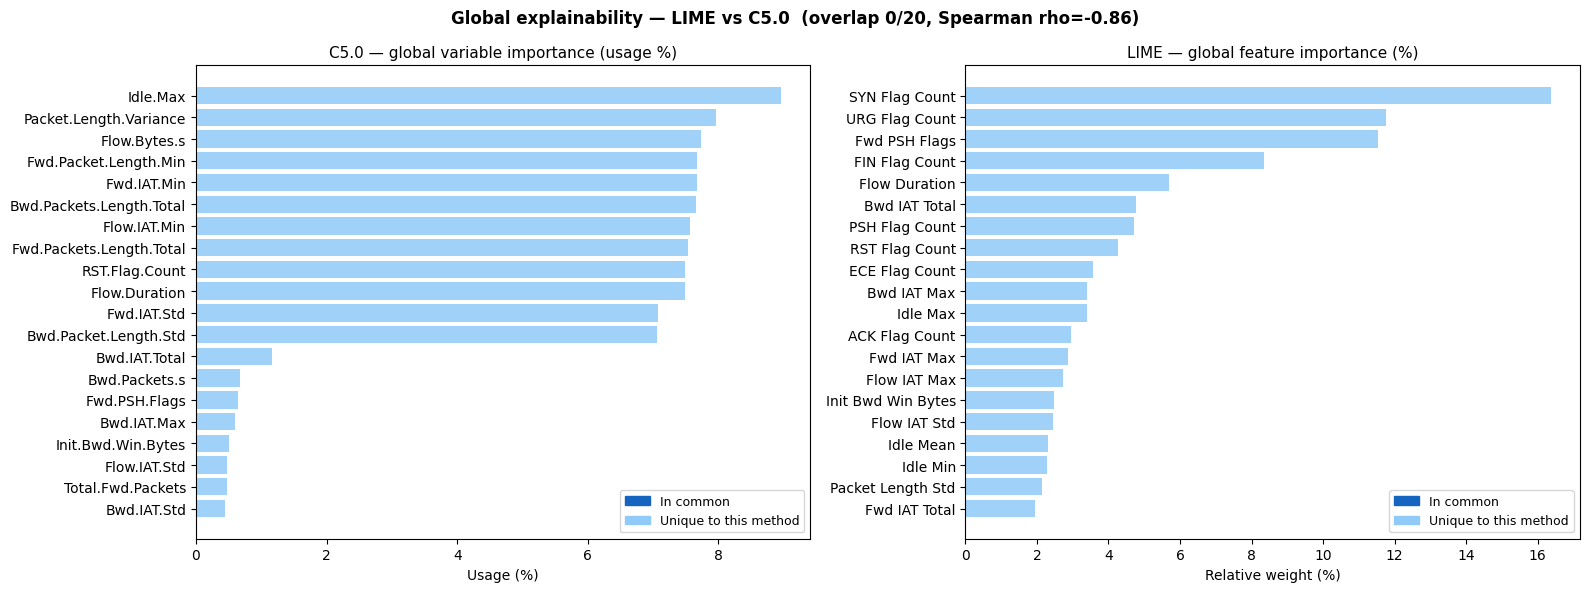

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

c50_plot  = c50_imp.head(TOP_N).copy().sort_values("usage_pct")
lime_plot = lime_global_imp.head(TOP_N).copy()
lime_plot["pct"] = lime_plot["mean_abs_weight"] / lime_plot["mean_abs_weight"].sum() * 100
lime_plot = lime_plot.sort_values("pct")

for ax, data, col, title, xlabel in [
    (axes[0], c50_plot,  "usage_pct", "C5.0 — global variable importance (usage %)", "Usage (%)"),
    (axes[1], lime_plot, "pct",       "LIME — global feature importance (%)",        "Relative weight (%)"),
]:
    colors = ["#1565c0" if f in common else "#90caf9" for f in data["feature"]]
    ax.barh(data["feature"], data[col], color=colors, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    common_patch = mpatches.Patch(color="#1565c0", label="In common")
    unique_patch  = mpatches.Patch(color="#90caf9", label="Unique to this method")
    ax.legend(handles=[common_patch, unique_patch], fontsize=9)

plt.suptitle(
    f"Global explainability — LIME vs C5.0  "
    f"(overlap {len(common)}/{TOP_N}, Spearman rho={rho:.2f})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(LIME_OUTDIR, "global_lime_vs_c50_ids2017.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5 — C5.0 importance per attack type

For each attack type, train a C5.0 surrogate on **that attack vs BENIGN** (one-vs-rest).  
Target = 1 if `attack_type == atype`, else 0. This captures what distinguishes each specific attack.


In [ ]:
C50_PERTYPE_DIR = os.path.join(C50_OUTDIR, "per_attack_type")
os.makedirs(C50_PERTYPE_DIR, exist_ok=True)

attack_types = (
    df[df["attack_type"].str.upper() != "BENIGN"]["attack_type"]
    .value_counts()
    .index.tolist()
)
print(f"Attack types to process ({len(attack_types)}): {attack_types}")

Attack types to process (14): ['DoS Hulk', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'SSH-Patator', 'PortScan', 'Web Attack � Brute Force', 'Bot', 'Web Attack � XSS', 'Infiltration', 'Web Attack � Sql Injection', 'Heartbleed']


In [14]:
c50_per_type_imp = {}

R_TEMPLATE = """
library(C50)
tr <- read.csv("{TRAIN_PATH}", stringsAsFactors=TRUE)
te <- read.csv("{TEST_PATH}",  stringsAsFactors=TRUE)
tr$target_surrogate <- as.factor(tr$target_surrogate)
te$target_surrogate <- as.factor(te$target_surrogate)
for (col in names(tr)) {
  if (is.factor(tr[[col]]) && col != "target_surrogate") {
    te[[col]] <- factor(te[[col]], levels=levels(tr[[col]]))
  }
}
mod <- C5.0(subset(tr, select=-c(target_surrogate)), tr$target_surrogate, trials=1)

imp_df <- tryCatch({
  imp <- C5imp(mod, metric="usage")
  data.frame(feature=row.names(imp), usage=imp[,1], row.names=NULL)
}, error = function(e) NULL)

if (is.null(imp_df)) {
  model_text <- capture.output(summary(mod))
  usage_start <- grep("Attribute usage", model_text)
  if (length(usage_start) > 0) {
    usage_lines <- model_text[(usage_start+2):length(model_text)]
    end_idx <- which(trimws(usage_lines) == "")
    if (length(end_idx) > 0) usage_lines <- usage_lines[1:(end_idx[1]-1)]
    parsed   <- regmatches(usage_lines, regexpr("([0-9]+[.]?[0-9]*)%[[:space:]]+(.+)", usage_lines))
    features <- gsub("([0-9]+[.]?[0-9]*)%[[:space:]]+(.+)", "\\2", parsed)
    usages   <- as.numeric(gsub("([0-9]+[.]?[0-9]*)%[[:space:]]+(.+)", "\\1", parsed))
    imp_df   <- data.frame(feature=trimws(features), usage=usages, row.names=NULL)
  } else {
    tree_text <- capture.output(mod)
    node_line <- grep("^[[:space:]]*[a-zA-Z]", tree_text, value=TRUE)
    feat <- trimws(gsub("[^a-zA-Z0-9._].*", "", node_line[1]))
    imp_df <- data.frame(feature=feat, usage=100.0, row.names=NULL)
    cat("STUMP detected, root feature:", feat, "\\n")
  }
}

imp_df <- imp_df[order(-imp_df$usage), ]
write.csv(imp_df, "{IMP_PATH}", row.names=FALSE)
cat("OK\\n")
"""

for atype in attack_types:
    atype_clean = atype.encode('ascii', errors='ignore').decode('ascii').strip()
    atype_safe  = re.sub(r'[^\w\-]', '_', atype_clean.replace(" ", "_"))
    atype_dir   = os.path.join(C50_PERTYPE_DIR, atype_safe)
    os.makedirs(atype_dir, exist_ok=True)

    sub = df[
        (df["attack_type"] == atype) |
        (df["attack_type"].str.upper() == "BENIGN")
    ].copy()

    sub["attack_type_clean"] = sub["attack_type"].apply(
        lambda x: x.encode('ascii', errors='ignore').decode('ascii').strip()
    )
    sub["target_surrogate"] = (sub["attack_type_clean"] == atype_clean).astype(int).astype(str)

    if sub["target_surrogate"].nunique() < 2:
        print(f"[SKIP] {atype} — only one class in target")
        continue

    X_sub = sub[feature_cols]
    y_sub = sub["target_surrogate"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sub, y_sub, test_size=0.3, random_state=42, stratify=y_sub
    )

    tr_df = X_tr.copy(); tr_df["target_surrogate"] = y_tr.values
    te_df = X_te.copy(); te_df["target_surrogate"]  = y_te.values

    train_path = os.path.join(atype_dir, "train.csv").replace("\\", "/")
    test_path  = os.path.join(atype_dir, "test.csv").replace("\\", "/")
    imp_path   = os.path.join(atype_dir, "importance.csv").replace("\\", "/")

    tr_df.to_csv(train_path, index=False)
    te_df.to_csv(test_path,  index=False)

    r_script = R_TEMPLATE.replace("{TRAIN_PATH}", train_path) \
                         .replace("{TEST_PATH}",  test_path) \
                         .replace("{IMP_PATH}",   imp_path)

    rscript_file = os.path.join(atype_dir, "run.R")
    with open(rscript_file, "w", encoding="utf-8") as f:
        f.write(r_script)

    res = subprocess.run(
        [rscript_path, rscript_file],
        capture_output=True, text=True, encoding='utf-8', errors='replace'
    )
    if res.returncode != 0:
        print(f"[ERROR] {atype}")
        print("STDOUT:", res.stdout)
        print("STDERR:", res.stderr)
        continue

    imp_path_local = os.path.join(atype_dir, "importance.csv")
    if not os.path.exists(imp_path_local):
        print(f"[ERROR] {atype}: importance.csv não criado"); continue

    imp_df = pd.read_csv(imp_path_local).sort_values("usage", ascending=False).reset_index(drop=True)
    c50_per_type_imp[atype] = imp_df
    print(f"[OK] {atype}: {len(imp_df)} features")

print(f"\nDone — {len(c50_per_type_imp)} attack types processed.")

[OK] DoS Hulk: 77 features
[OK] DDoS: 77 features
[OK] DoS GoldenEye: 77 features
[OK] FTP-Patator: 77 features
[OK] DoS slowloris: 77 features
[OK] DoS Slowhttptest: 77 features
[OK] SSH-Patator: 77 features
[OK] PortScan: 77 features
[OK] Web Attack � Brute Force: 1 features
[OK] Bot: 1 features
[OK] Web Attack � XSS: 1 features
[OK] Infiltration: 1 features
[OK] Web Attack � Sql Injection: 1 features
[OK] Heartbleed: 1 features

Done — 14 attack types processed.


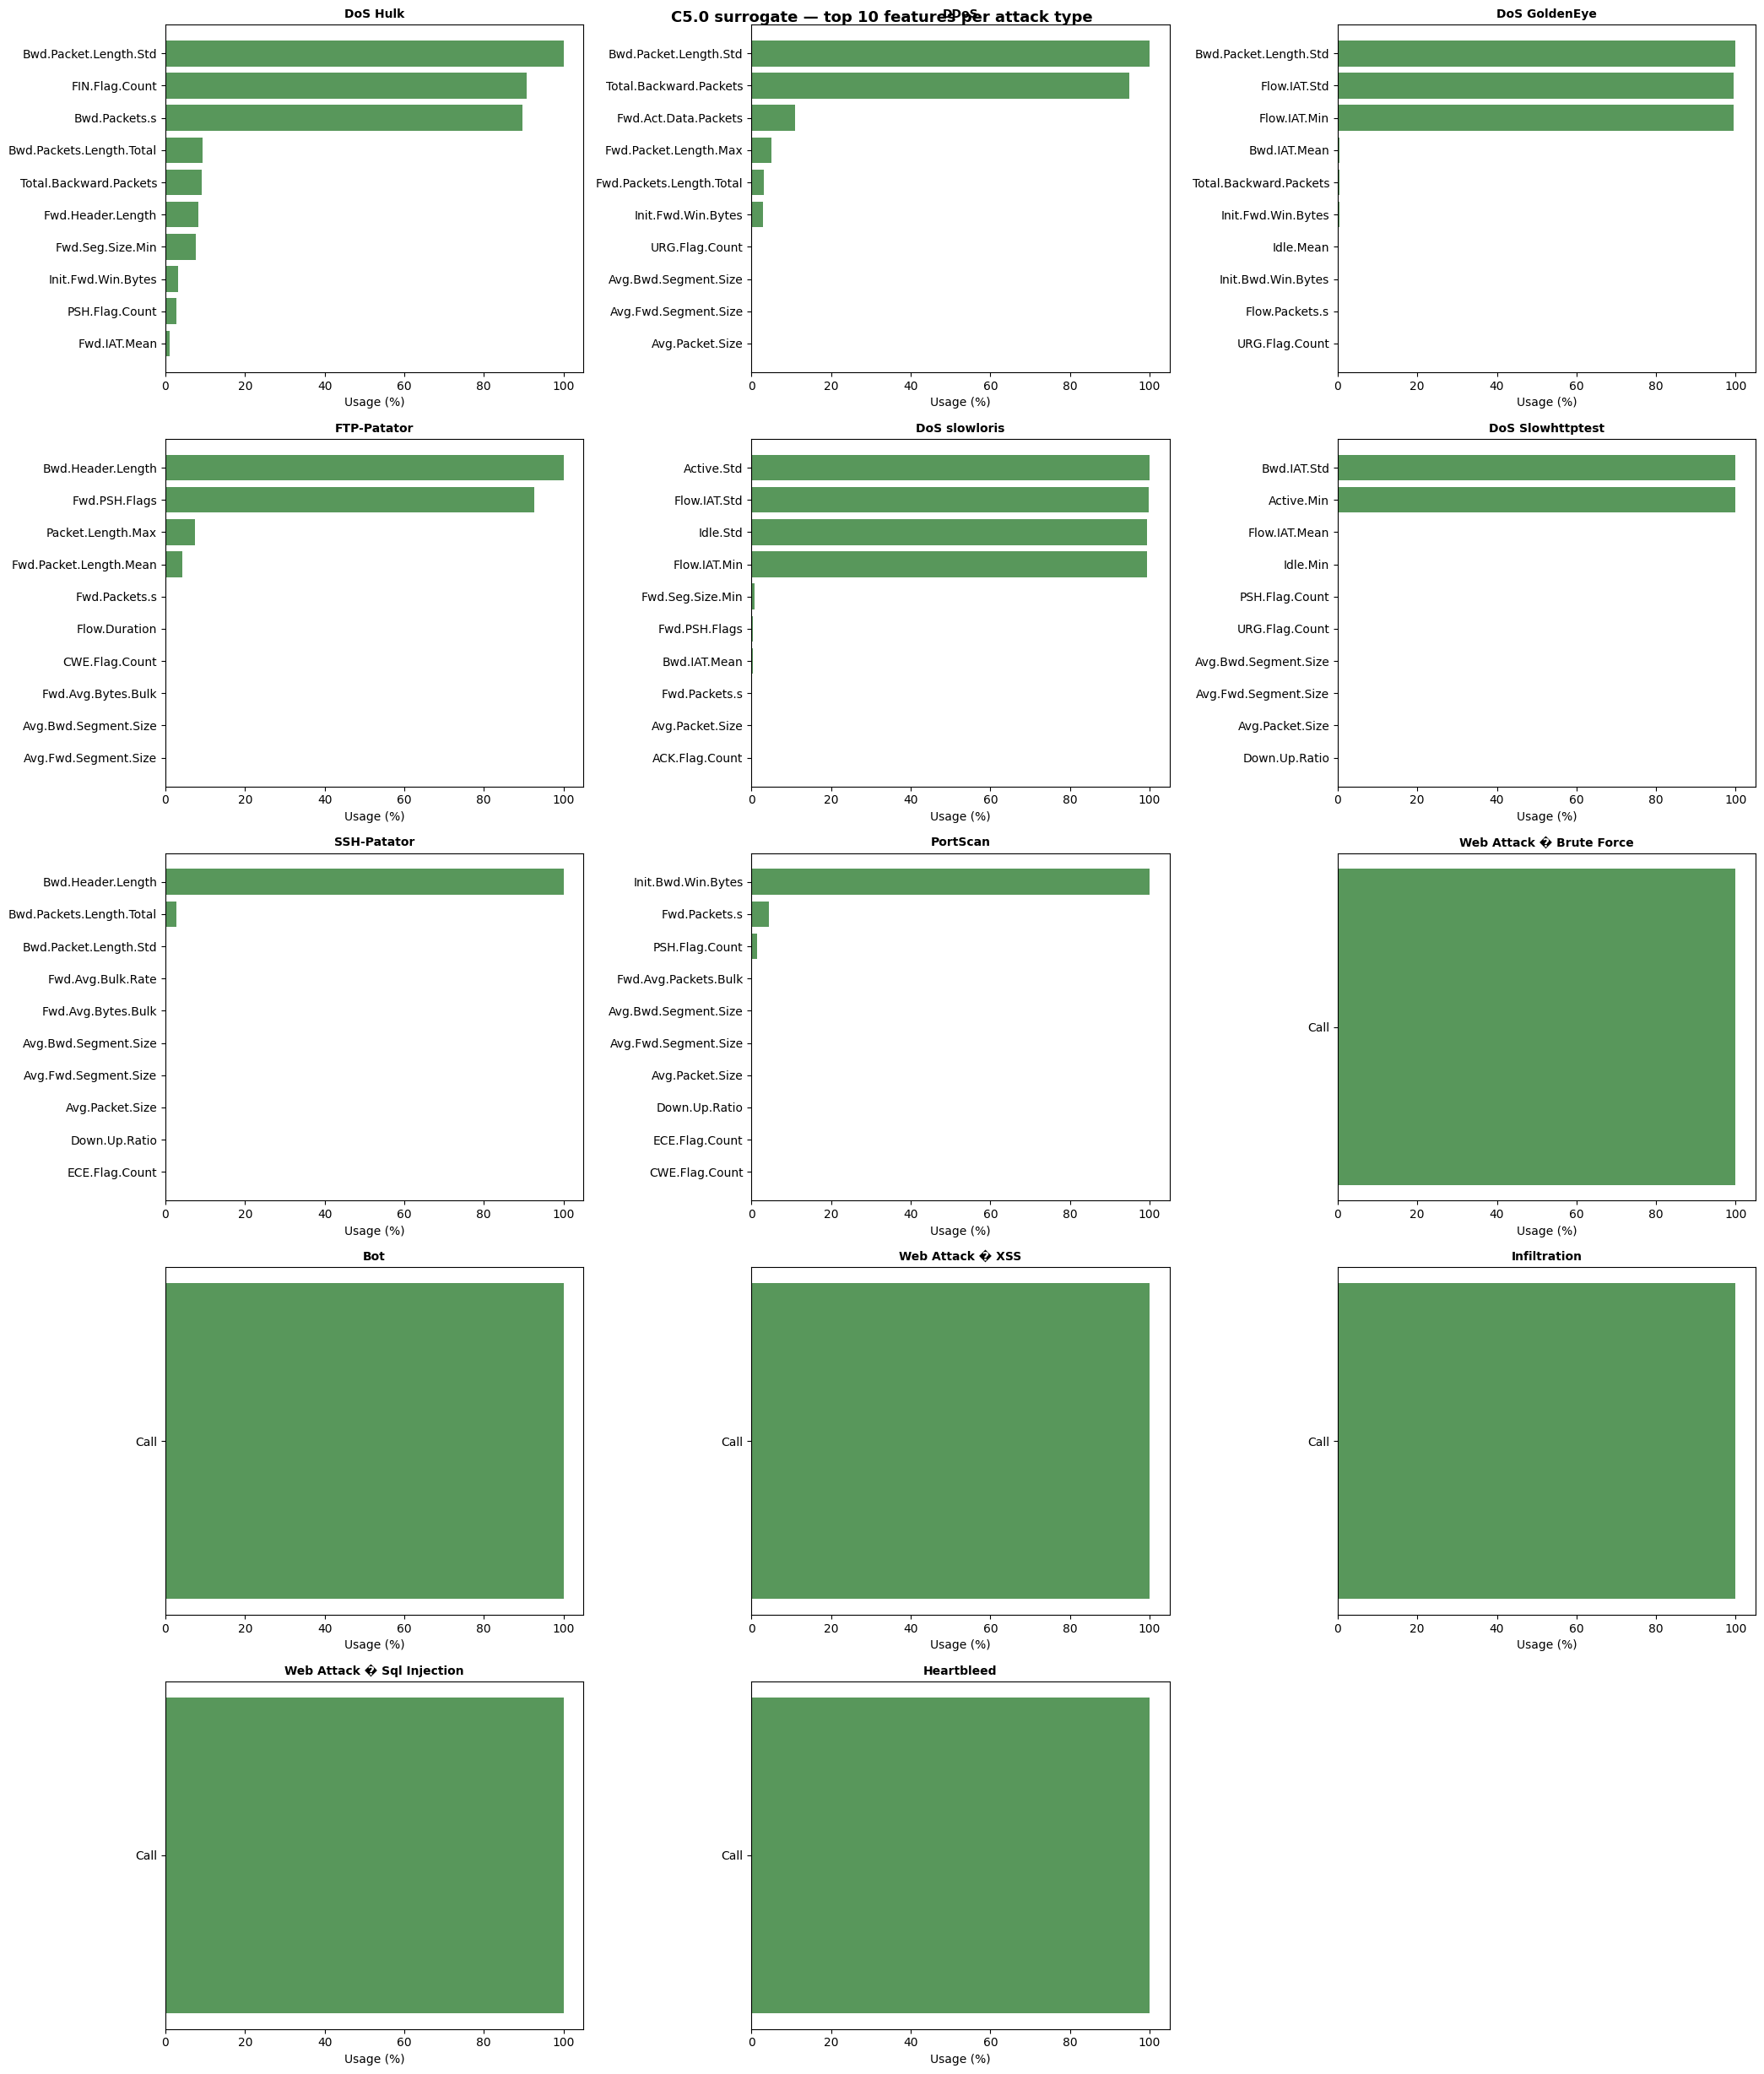

In [ ]:
n_types = len(c50_per_type_imp)
n_cols  = min(3, n_types)
n_rows  = math.ceil(n_types / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for i, (atype, imp_df) in enumerate(c50_per_type_imp.items()):
    top10 = imp_df.head(10)
    axes[i].barh(top10["feature"][::-1], top10["usage"][::-1], color="#2e7d32", alpha=0.8)
    axes[i].set_title(atype, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Usage (%)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("C5.0 surrogate — top 10 features per attack type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(C50_OUTDIR, "c50_per_attack_type_ids2017.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6 — LIME importance per attack type


In [ ]:
N_PER_TYPE = 500

lime_per_type_imp = {}
attack_type_codes = {atype: i for i, atype in enumerate(sorted(df["attack_type"].unique()))}

for atype in attack_types:
    positions = (
        df[(df["attack_type"] == atype)]
        .index.tolist()[:N_PER_TYPE]
    )
    if not positions:
        print(f"  [SKIP] {atype} — no examples"); continue

    def make_ovr_wrapper(target_atype):
        def predict_proba_ovr(X_arr):
            probs = []
            for row in X_arr:
                x_dict = {}
                for i, feat in enumerate(wrapper.feat):
                    val = row[i]
                    x_dict[feat] = float(val) if feat in wrapper.num_set else str(val)
                score = wrapper.model.score_one(x_dict)
                probs.append([1 - score, score])
            return np.array(probs)
        return predict_proba_ovr

    # Explainer local
    sub_idx = (
        df[(df["attack_type"] == atype) | (df["attack_type"].str.upper() == "BENIGN")]
        .index.tolist()
    )
    X_sub_train = X_lime_num.values[sub_idx].astype(float)

    explainer_ovr = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_sub_train,
        feature_names=feature_cols,
        class_names=["Benign", atype],
        categorical_features=[feature_cols.index(c) for c in cat_cols],
        mode="classification",
        random_state=42
    )

    ovr_predict = make_ovr_wrapper(atype)

    feat_weights = collections.defaultdict(float)
    for pos in positions:
        exp = explainer_ovr.explain_instance(
            data_row=X_lime_num.values[pos],
            predict_fn=ovr_predict,
            num_features=len(feature_cols),
            labels=(1,)
        )
        for feat, weight in exp.as_list(label=1):
            fname = extract_feature_name(feat, feature_cols)
            if fname:
                feat_weights[fname] += abs(weight)

    n = len(positions)
    lime_per_type_imp[atype] = pd.DataFrame({
        "feature"       : list(feat_weights.keys()),
        "avg_abs_weight": [v/n for v in feat_weights.values()]
    }).sort_values("avg_abs_weight", ascending=False).reset_index(drop=True)

    lime_per_type_imp[atype].to_csv(
        os.path.join(LIME_OUTDIR, f"lime_{atype.replace(' ','_')}.csv"), index=False
    )
    print(f"  [OK] {atype}: {n} examples")

print(f"\nDone — {len(lime_per_type_imp)} attack types processed.")


  [OK] DoS Hulk: 500 examples
  [OK] DDoS: 500 examples
  [OK] DoS GoldenEye: 500 examples
  [OK] FTP-Patator: 500 examples
  [OK] DoS slowloris: 500 examples
  [OK] DoS Slowhttptest: 500 examples
  [OK] SSH-Patator: 500 examples
  [OK] PortScan: 500 examples
  [OK] Web Attack � Brute Force: 500 examples
  [OK] Bot: 500 examples
  [OK] Web Attack � XSS: 500 examples
  [OK] Infiltration: 36 examples
  [OK] Web Attack � Sql Injection: 21 examples
  [OK] Heartbleed: 11 examples

Done — 14 attack types processed.


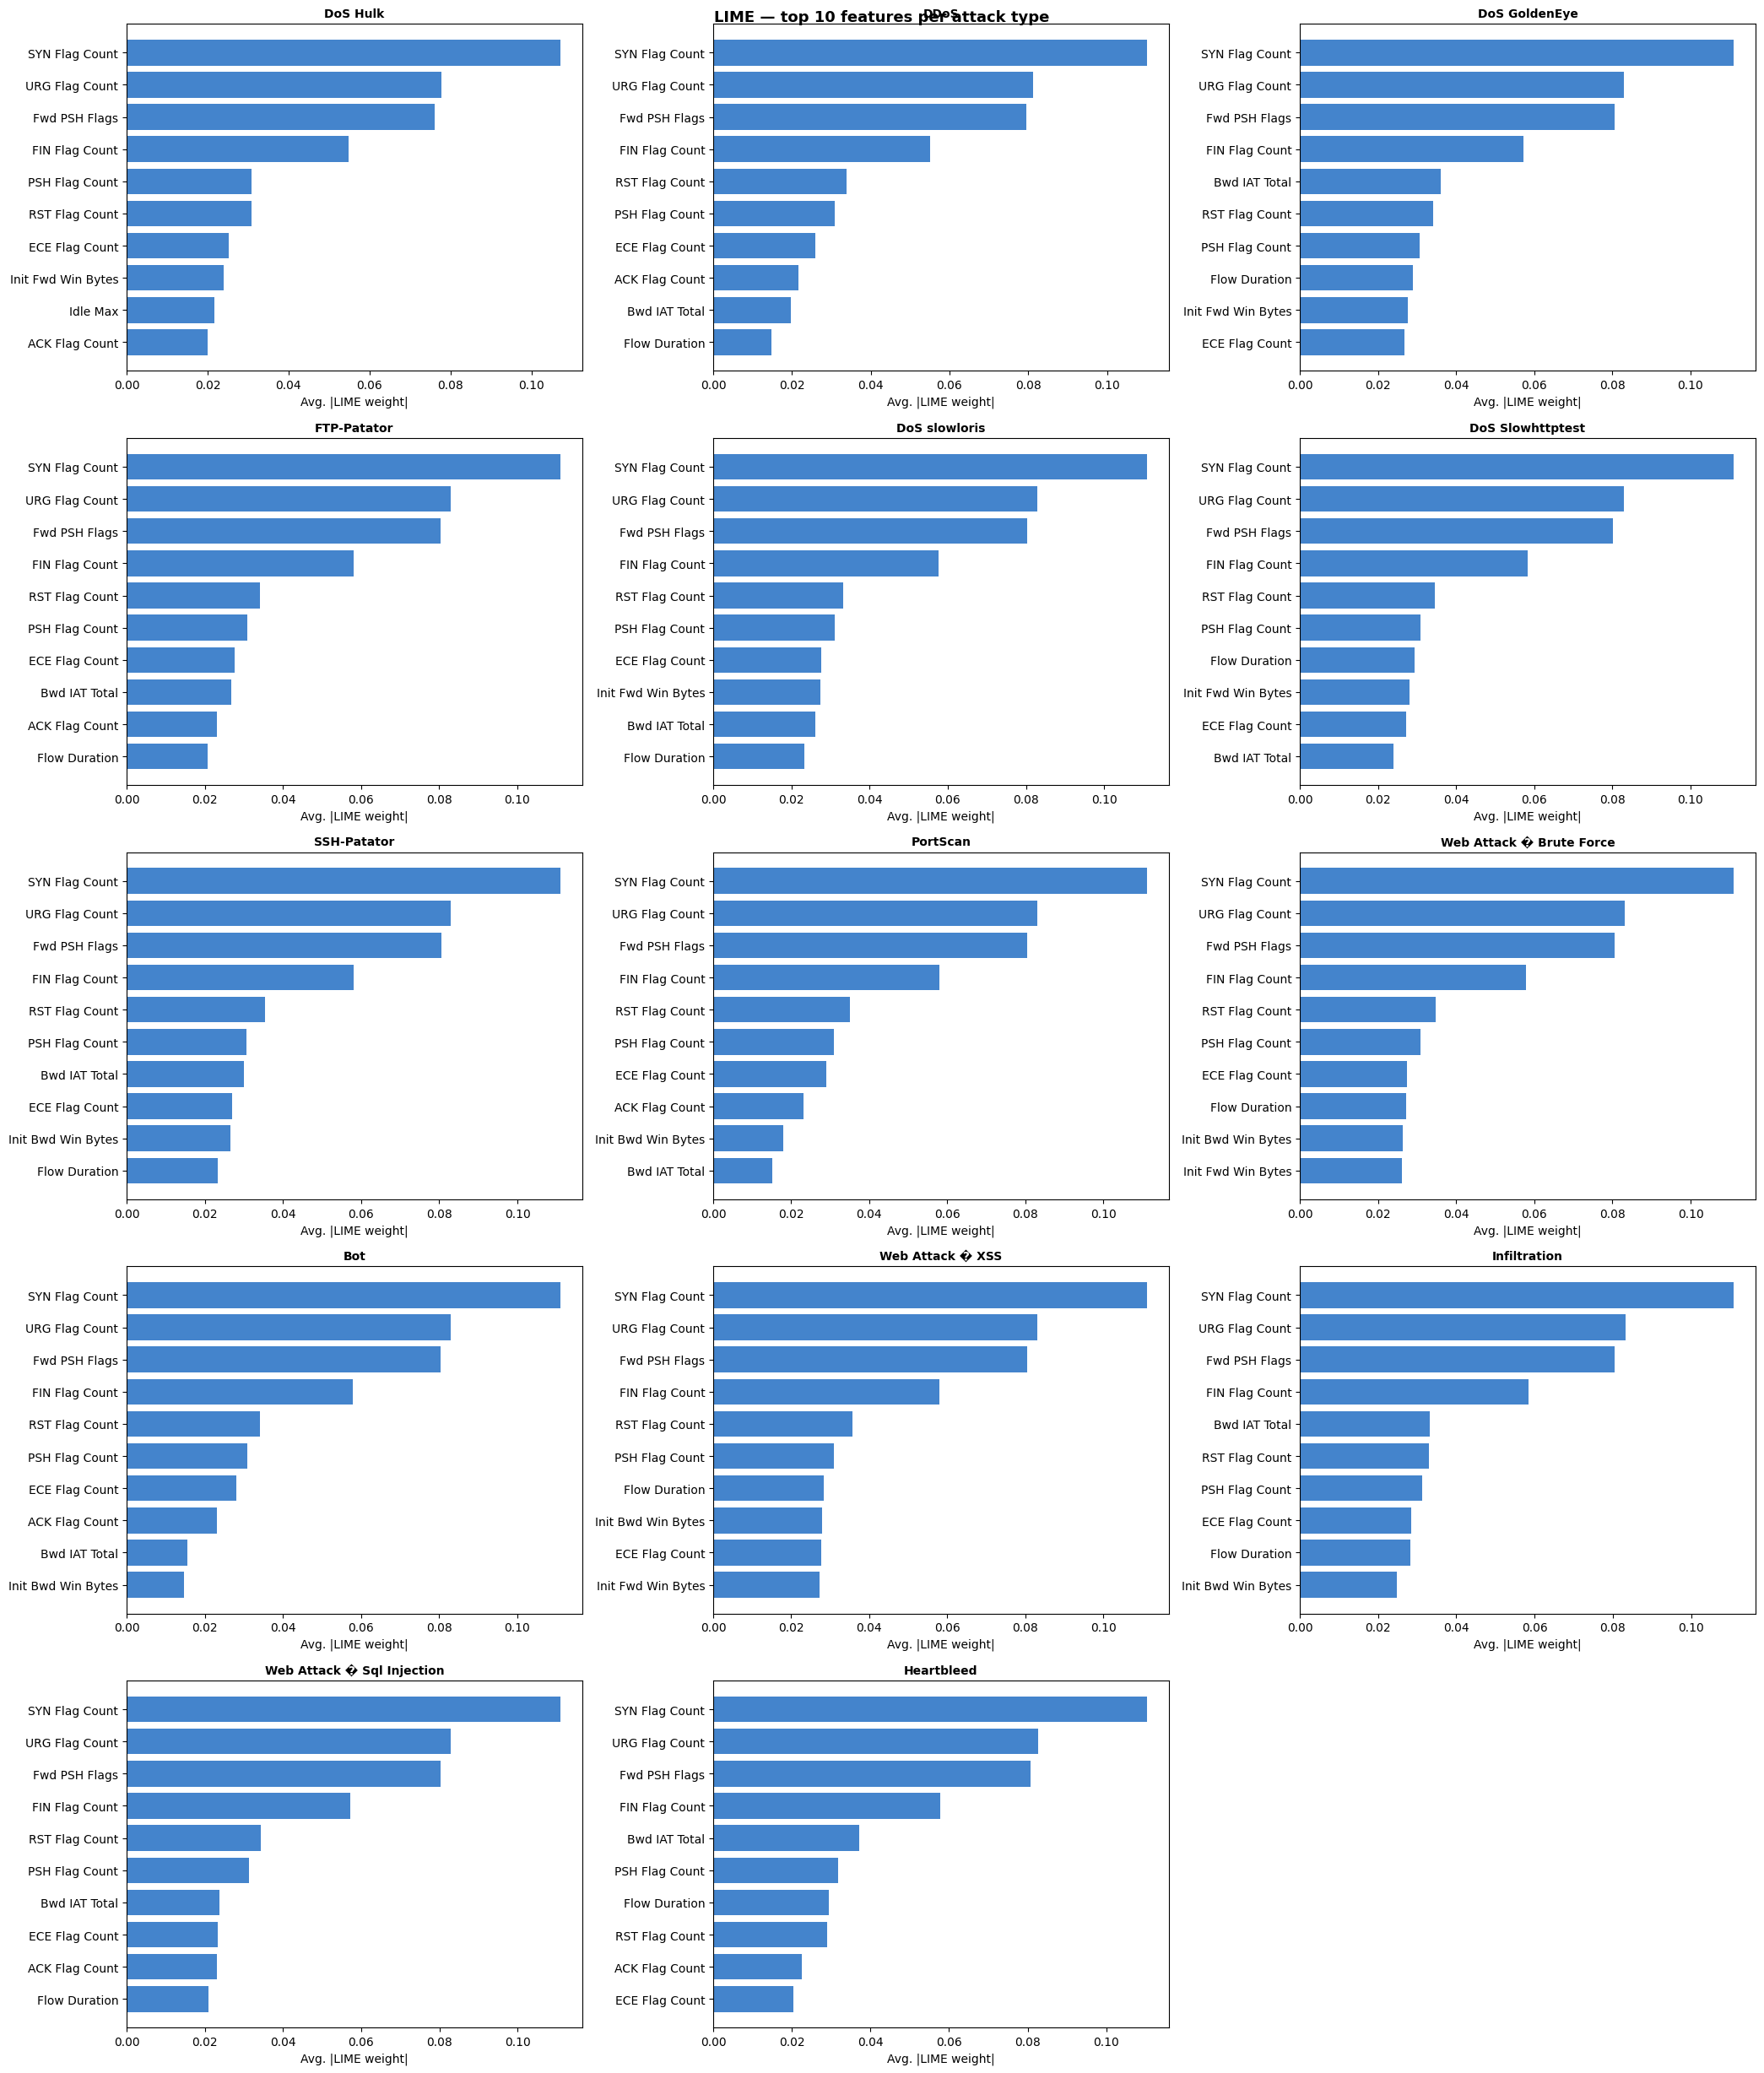

In [ ]:
n_types = len(lime_per_type_imp)
n_cols  = min(3, n_types)
n_rows  = math.ceil(n_types / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for i, (atype, imp_df) in enumerate(lime_per_type_imp.items()):
    top10 = imp_df.head(10)
    axes[i].barh(top10["feature"][::-1], top10["avg_abs_weight"][::-1], color="#1565c0", alpha=0.8)
    axes[i].set_title(atype, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Avg. |LIME weight|")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("LIME — top 10 features per attack type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(LIME_OUTDIR, "lime_per_attack_type_ids2017.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7 — LIME vs C5.0 per attack type

In [ ]:
TOP_K = 10
overlap_per_type = {}

common_types = sorted(set(lime_per_type_imp) & set(c50_per_type_imp))

for atype in common_types:
    top_lime_k = set(lime_per_type_imp[atype].head(TOP_K)["feature"])
    top_c50_k  = set(c50_per_type_imp[atype].head(TOP_K)["feature"])
    common_k   = top_lime_k & top_c50_k
    overlap_per_type[atype] = {
        "common"   : sorted(common_k),
        "only_lime": sorted(top_lime_k - top_c50_k),
        "only_c50" : sorted(top_c50_k - top_lime_k),
        "overlap_n": len(common_k)
    }

overlap_df = pd.DataFrame([
    {"attack_type": a, **{k: str(v) for k, v in d.items()}}
    for a, d in overlap_per_type.items()
])
overlap_df.to_csv(os.path.join(LIME_OUTDIR, "overlap_per_attack_type_ids2017.csv"), index=False)
print(overlap_df[["attack_type","overlap_n","common"]].to_string(index=False))

               attack_type overlap_n common
                       Bot         0     []
                      DDoS         0     []
             DoS GoldenEye         0     []
                  DoS Hulk         0     []
          DoS Slowhttptest         0     []
             DoS slowloris         0     []
               FTP-Patator         0     []
                Heartbleed         0     []
              Infiltration         0     []
                  PortScan         0     []
               SSH-Patator         0     []
  Web Attack � Brute Force         0     []
Web Attack � Sql Injection         0     []
          Web Attack � XSS         0     []


## 8 — TP / FP analysis per attack type

C:\Users\Matilde\AppData\Local\Temp\ipykernel_14492\1252381468.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("RdYlGn")


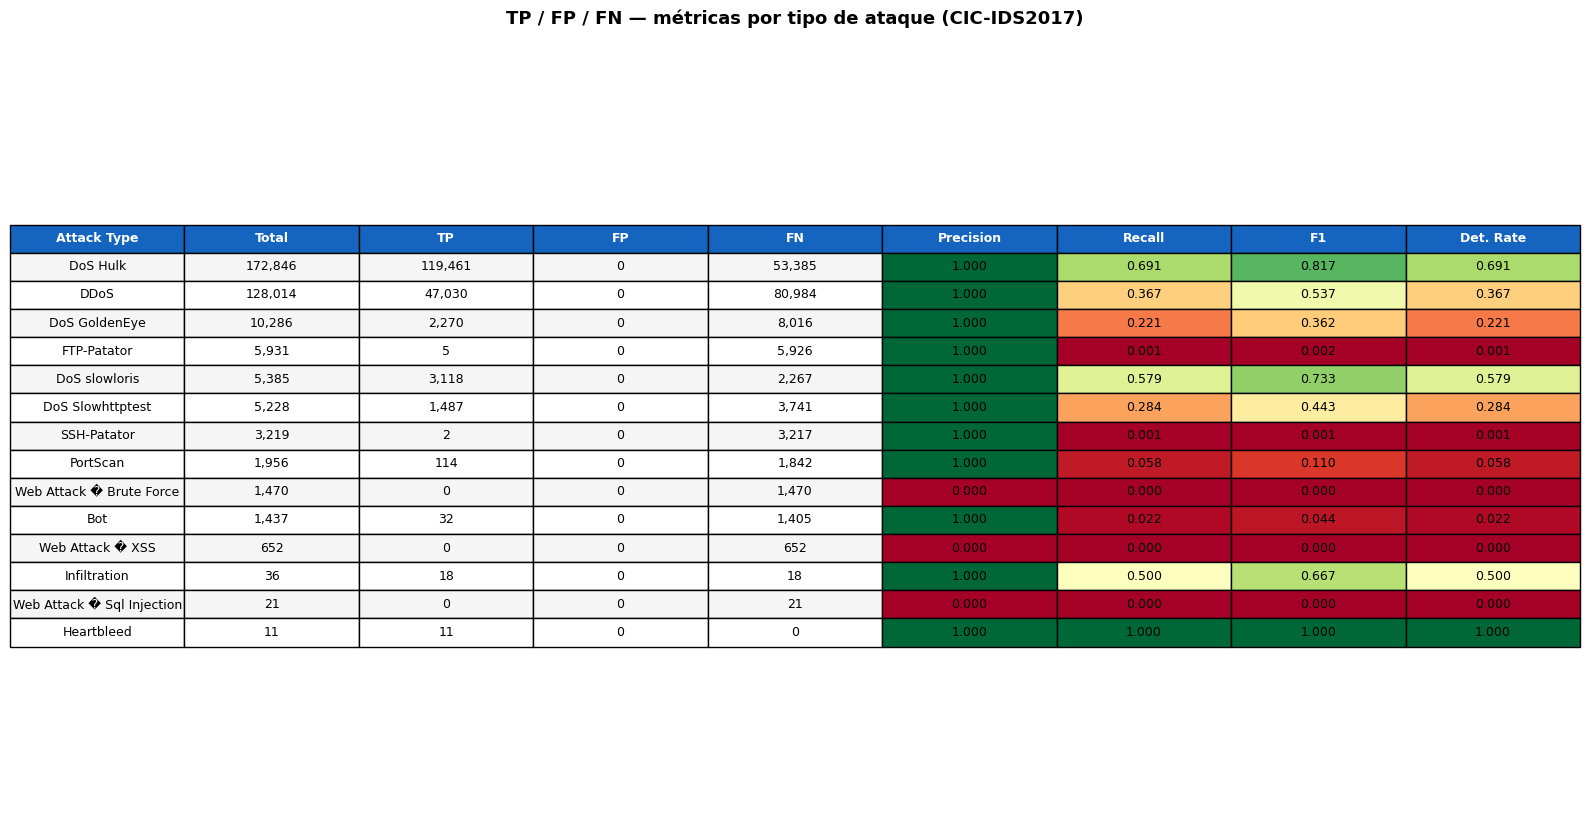

In [19]:
records = []

for atype in sorted(df["attack_type"].unique()):
    sub = df[df["attack_type"] == atype]

    tp = int(((sub["y_true"] == 1) & (sub["y_pred"] == 1)).sum())
    fp = int(((sub["y_true"] == 0) & (sub["y_pred"] == 1)).sum())
    tn = int(((sub["y_true"] == 0) & (sub["y_pred"] == 0)).sum())
    fn = int(((sub["y_true"] == 1) & (sub["y_pred"] == 0)).sum())

    total = len(sub)
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1    = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0.0
    det   = tp / total if total > 0 else 0.0

    records.append({
        "attack_type"   : atype,
        "total"         : total,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"     : round(prec, 4),
        "recall"        : round(rec, 4),
        "f1"            : round(f1, 4),
        "detection_rate": round(det, 4)
    })

stats_df = pd.DataFrame(records).sort_values("total", ascending=False).reset_index(drop=True)
stats_df.to_csv(os.path.join(C50_OUTDIR, "tp_fp_per_attack_type_ids2017.csv"), index=False)

display_cols = ["attack_type","total","tp","fp","fn","precision","recall","f1","detection_rate"]
table_df = stats_df[stats_df["attack_type"].str.upper() != "BENIGN"][display_cols].copy()

fig, ax = plt.subplots(figsize=(16, len(table_df) * 0.5 + 1.5))
ax.axis("off")

col_labels = ["Attack Type","Total","TP","FP","FN","Precision","Recall","F1","Det. Rate"]
cell_text  = []
for _, row in table_df.iterrows():
    cell_text.append([
        row["attack_type"],
        f"{row['total']:,}",
        f"{row['tp']:,}",
        f"{row['fp']:,}",
        f"{row['fn']:,}",
        f"{row['precision']:.3f}",
        f"{row['recall']:.3f}",
        f"{row['f1']:.3f}",
        f"{row['detection_rate']:.3f}",
    ])

table = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565c0")
    table[0, j].set_text_props(color="white", fontweight="bold")

metric_cols = {"precision": 5, "recall": 6, "f1": 7, "detection_rate": 8}
for metric, col_idx in metric_cols.items():
    vals = table_df[metric].values
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.cm.get_cmap("RdYlGn")
    for row_idx, val in enumerate(vals):
        table[row_idx + 1, col_idx].set_facecolor(cmap(norm(val)))

for row_idx in range(len(table_df)):
    bg = "#f5f5f5" if row_idx % 2 == 0 else "white"
    for col_idx in range(5):
        table[row_idx + 1, col_idx].set_facecolor(bg)

plt.title("TP / FP / FN — métricas por tipo de ataque (CIC-IDS2017)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(C50_OUTDIR, "metrics_table_per_attack_ids2017.png"), dpi=150, bbox_inches="tight")
plt.show()